<a href="https://colab.research.google.com/github/SRET-College/Sem-6-NN-and-DL/blob/main/NN_and_DL_Expt_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Sat May  9 20:49:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
train_dir = os.path.join(path, 'chest_xray', 'train')
test_dir = os.path.join(path, 'chest_xray', 'test')

# Setup Generators (Simplified for speed)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255) # Removed augmentation for speed
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')
test_gen = test_datagen.flow_from_directory(test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')

def fast_train(model, name):
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    print(f"--- Fast Training {name} ---")
    # Training for 3 epochs with limited validation steps to save time
    history = model.fit(train_gen, epochs=3, validation_data=test_gen, validation_steps=10)
    tf.keras.backend.clear_session() # Frees RAM immediately
    return history


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
cnn = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
cnn_history = fast_train(cnn, "CNN")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--- Fast Training CNN ---
Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 85s 497ms/step - accuracy: 0.7293 - loss: 0.9859 - val_accuracy: 0.6313 - val_loss: 0.4719
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 55s 337ms/step - accuracy: 0.7464 - loss: 0.2865 - val_accuracy: 0.7719 - val_loss: 0.5957
Epoch 3/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 54s 330ms/step - accuracy: 0.9515 - loss: 0.2351 - val_accuracy: 0.8281 - val_loss: 0.4947


In [ ]:
alexnet = models.Sequential([
    layers.Conv2D(48, 11, strides=4, activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(3, strides=2),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
alexnet_history = fast_train(alexnet, "AlexNet")


--- Fast Training AlexNet ---
Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 56s 327ms/step - accuracy: 0.8825 - loss: 0.3689 - val_accuracy: 0.7750 - val_loss: 0.5038
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 54s 326ms/step - accuracy: 0.9578 - loss: 0.1208 - val_accuracy: 0.7500 - val_loss: 0.8389
Epoch 3/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 324ms/step - accuracy: 0.9565 - loss: 0.1162 - val_accuracy: 0.7094 - val_loss: 1.1203


In [ ]:
vgg16_base = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
vgg16_base.trainable = False
vgg16 = models.Sequential([vgg16_base, layers.GlobalAveragePooling2D(), layers.Dense(1, activation='sigmoid')])
vgg16_history = fast_train(vgg16, "VGG16")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
--- Fast Training VGG16 ---
Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 79s 390ms/step - accuracy: 0.7358 - loss: 0.5105 - val_accuracy: 0.6562 - val_loss: 0.5510
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 63s 388ms/step - accuracy: 0.7908 - loss: 0.3966 - val_accuracy: 0.6531 - val_loss: 0.5381
Epoch 3/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 62s 379ms/step - accuracy: 0.8616 - loss: 0.3341 - val_accuracy: 0.6875 - val_loss: 0.4973


In [ ]:
vgg19_base = tf.keras.applications.VGG19(weights='imagenet', include_top=False, input_shape=(224,224,3))
vgg19_base.trainable = False
vgg19 = models.Sequential([vgg19_base, layers.GlobalAveragePooling2D(), layers.Dense(1, activation='sigmoid')])
vgg19_history = fast_train(vgg19, "VGG19")


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
--- Fast Training VGG19 ---
Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 68s 407ms/step - accuracy: 0.7460 - loss: 0.4818 - val_accuracy: 0.6187 - val_loss: 0.6102
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 66s 405ms/step - accuracy: 0.8202 - loss: 0.3839 - val_accuracy: 0.6906 - val_loss: 0.5284
Epoch 3/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 81s 404ms/step - accuracy: 0.8589 - loss: 0.3360 - val_accuracy: 0.7625 - val_loss: 0.4569


In [ ]:
m_base = tf.keras.applications.MobileNet(weights='imagenet', include_top=False, input_shape=(224,224,3))
m_base.trainable = False
mobilenet = models.Sequential([m_base, layers.GlobalAveragePooling2D(), layers.Dense(1, activation='sigmoid')])
mobilenet_history = fast_train(mobilenet, "MobileNet")


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
--- Fast Training MobileNet ---
Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 73s 362ms/step - accuracy: 0.8746 - loss: 0.3081 - val_accuracy: 0.7781 - val_loss: 0.4267
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 54s 328ms/step - accuracy: 0.9567 - loss: 0.1313 - val_accuracy: 0.8094 - val_loss: 0.4068
Epoch 3/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 54s 330ms/step - accuracy: 0.9668 - loss: 0.1022 - val_accuracy: 0.8000 - val_loss: 0.4563


In [ ]:
x_base = tf.keras.applications.Xception(weights='imagenet', include_top=False, input_shape=(224,224,3))
x_base.trainable = False
xception = models.Sequential([x_base, layers.GlobalAveragePooling2D(), layers.Dense(1, activation='sigmoid')])
xception_history = fast_train(xception, "Xception")


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
--- Fast Training Xception ---
Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 89s 400ms/step - accuracy: 0.8970 - loss: 0.2592 - val_accuracy: 0.7969 - val_loss: 0.4731
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 62s 376ms/step - accuracy: 0.9433 - loss: 0.1513 - val_accuracy: 0.8094 - val_loss: 0.5188
Epoch 3/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 61s 375ms/step - accuracy: 0.9517 - loss: 0.1290 - val_accuracy: 0.7969 - val_loss: 0.5883


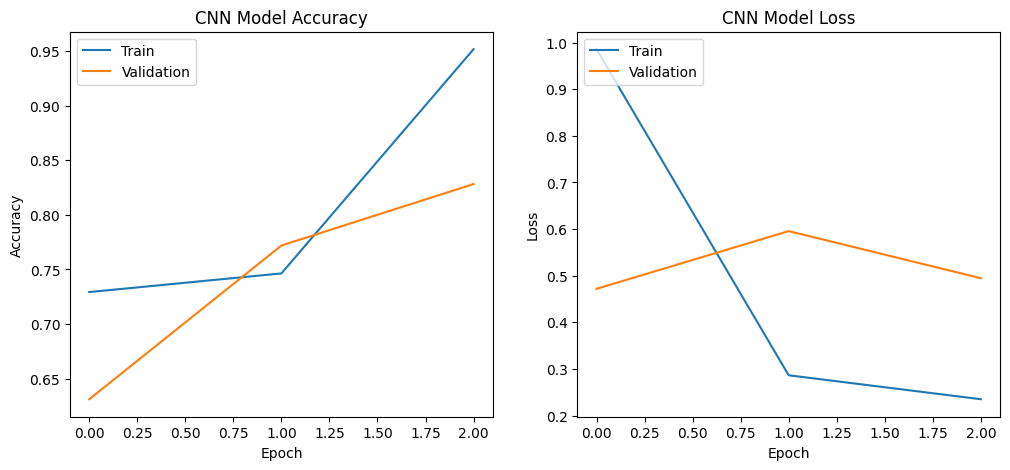

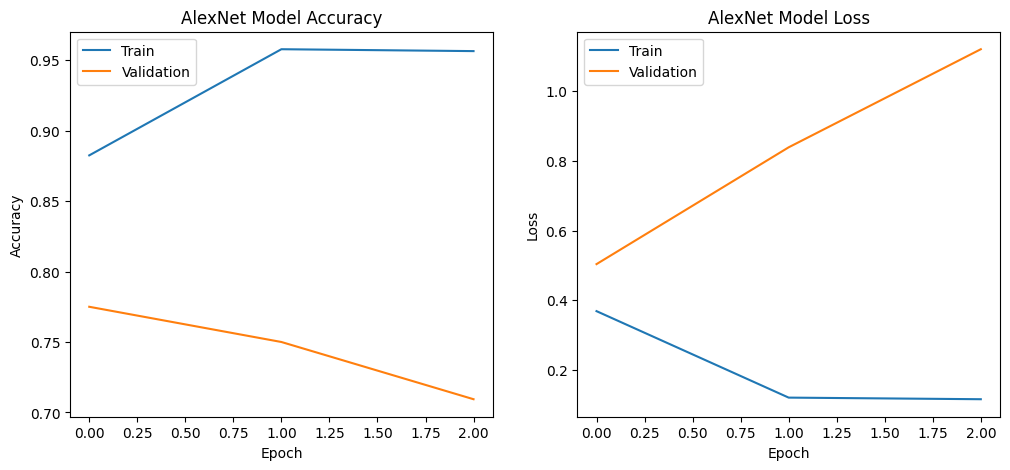

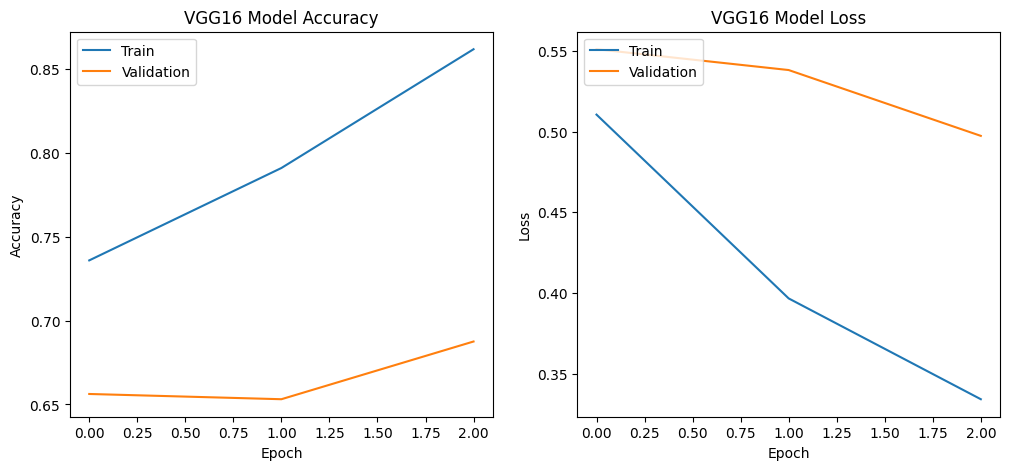

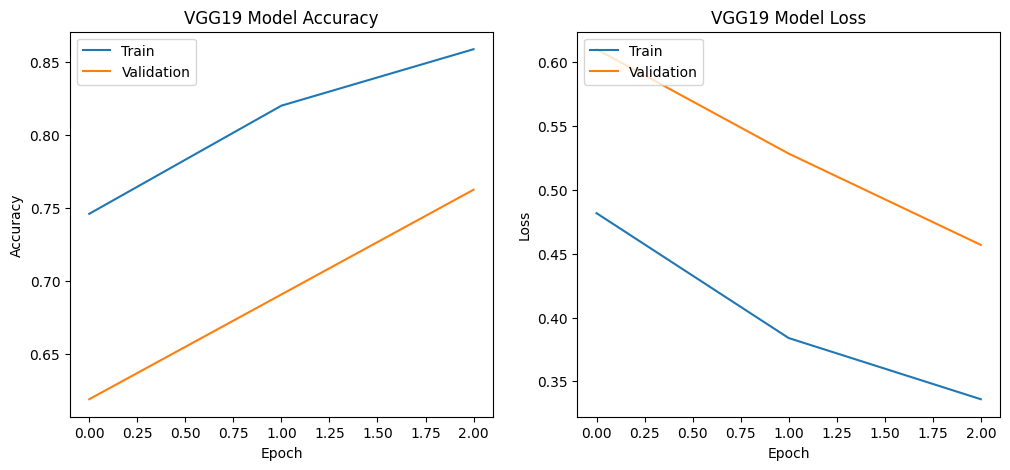

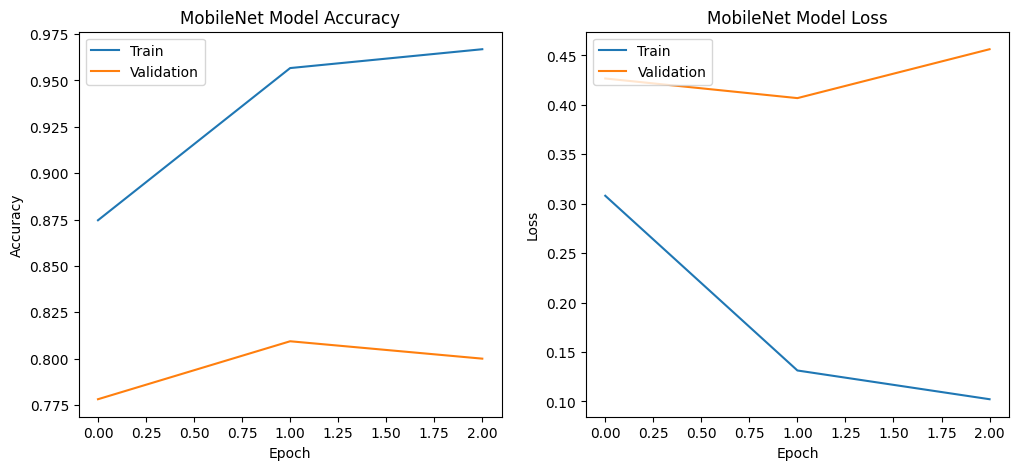

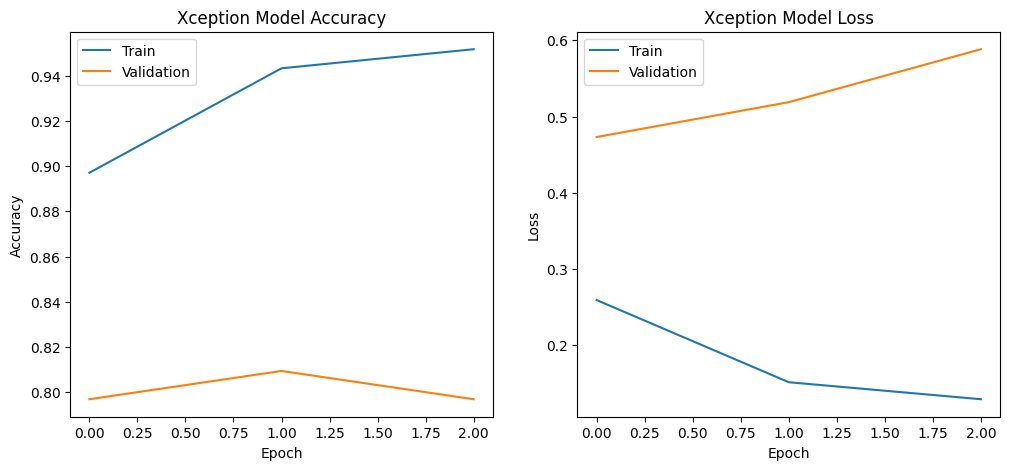

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{model_name} Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{model_name} Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()


plot_history(cnn_history, "CNN")
plot_history(alexnet_history, "AlexNet")
plot_history(vgg16_history, "VGG16")
plot_history(vgg19_history, "VGG19")
plot_history(mobilenet_history, "MobileNet")
plot_history(xception_history, "Xception")

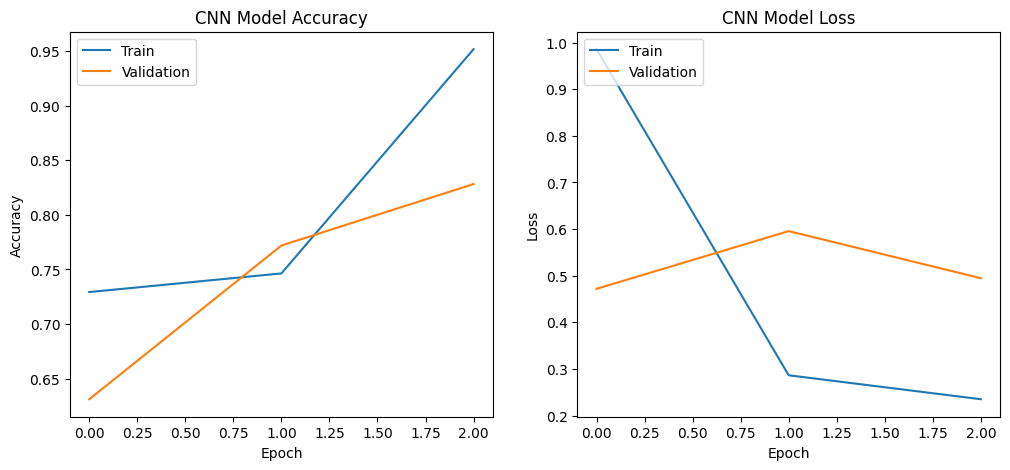

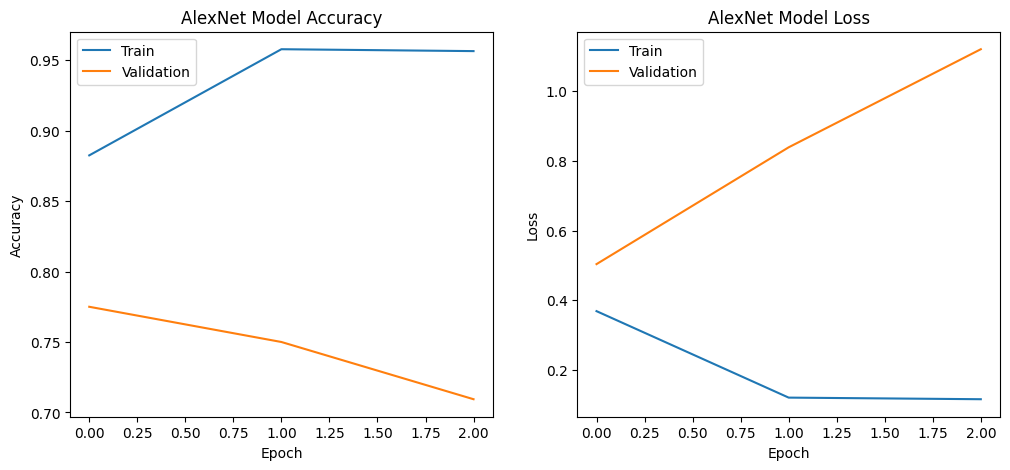

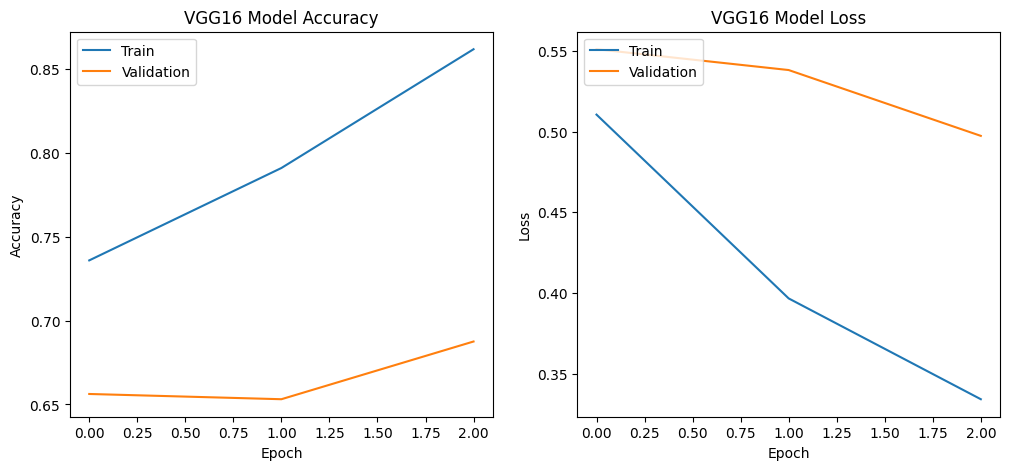

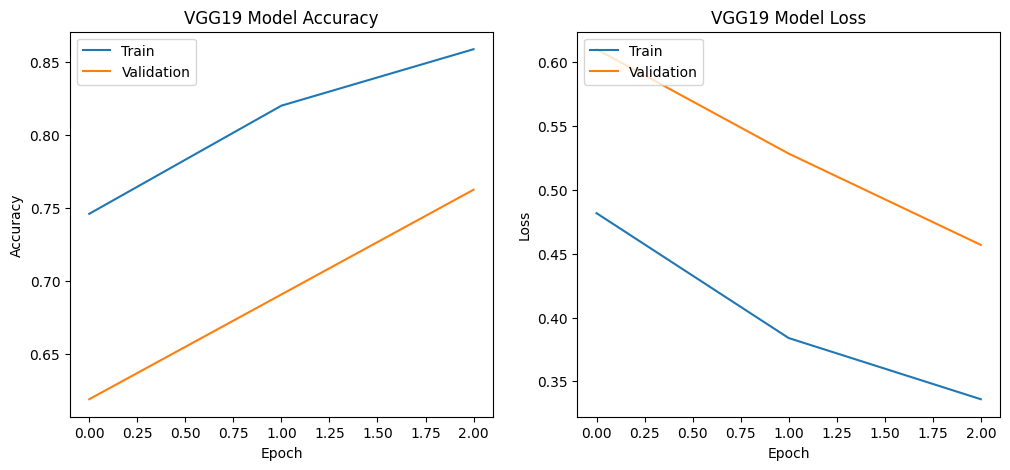

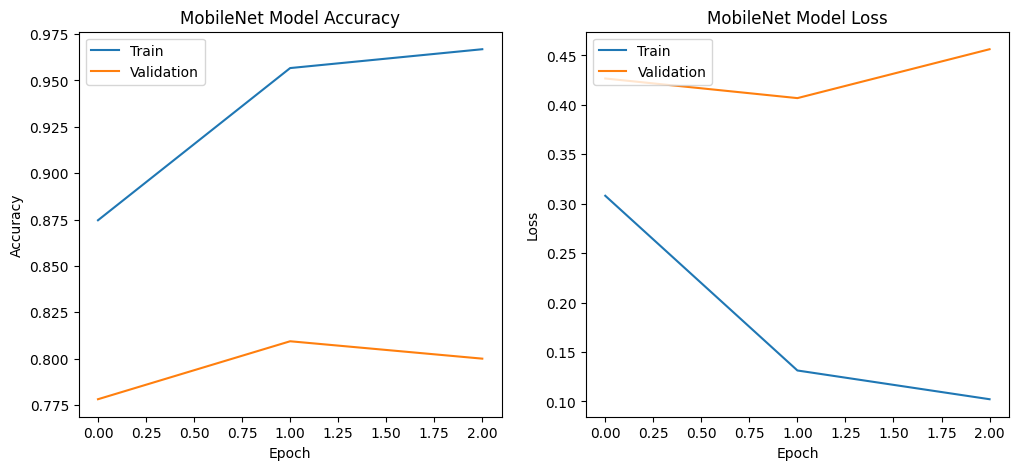

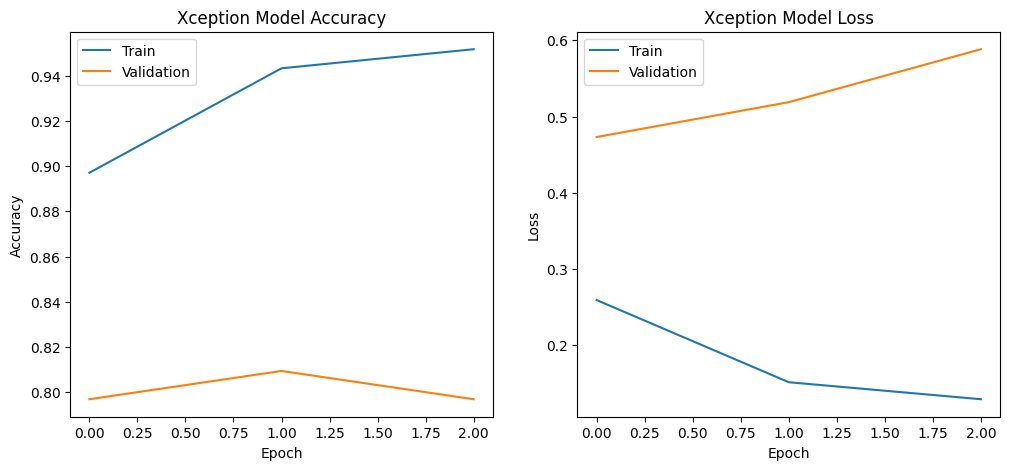

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{model_name} Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{model_name} Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()


plot_history(cnn_history, "CNN")
plot_history(alexnet_history, "AlexNet")
plot_history(vgg16_history, "VGG16")
plot_history(vgg19_history, "VGG19")
plot_history(mobilenet_history, "MobileNet")
plot_history(xception_history, "Xception")

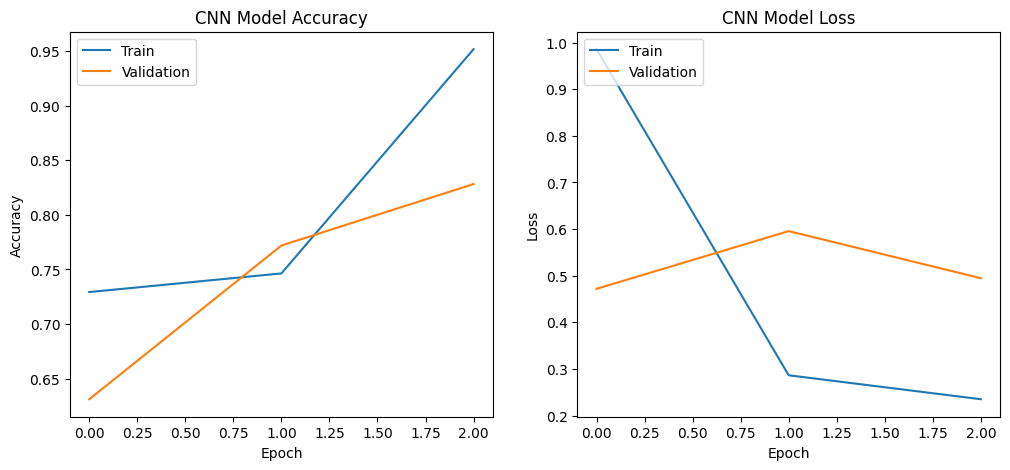

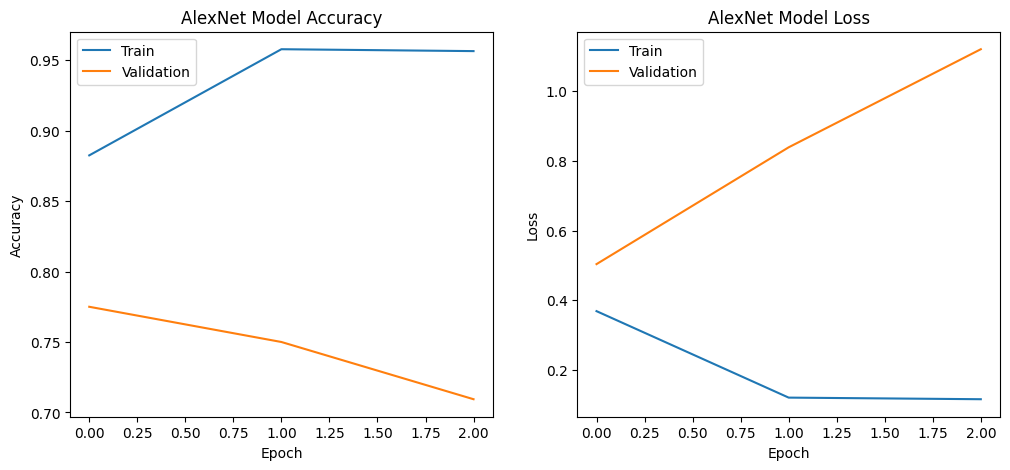

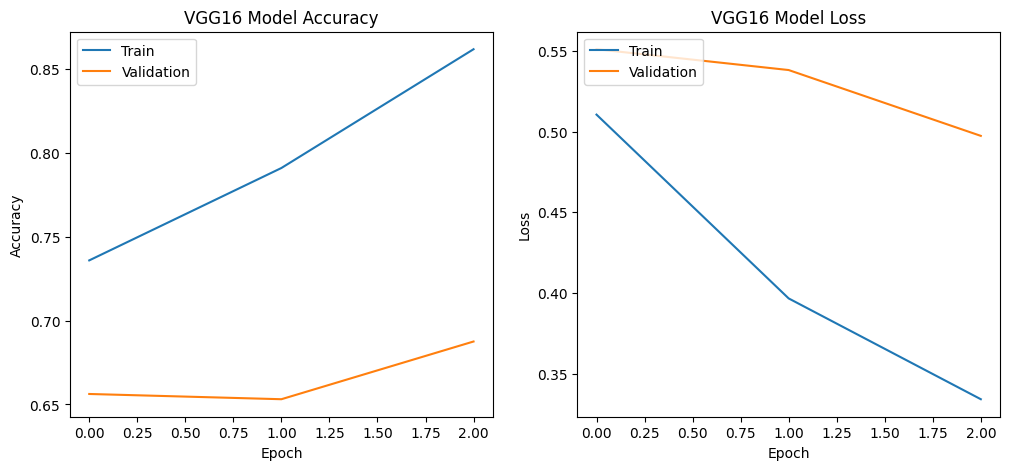

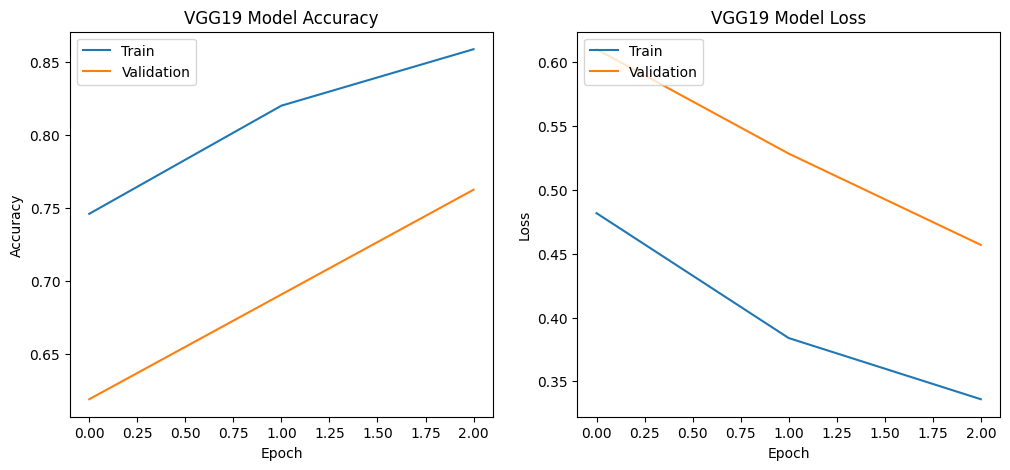

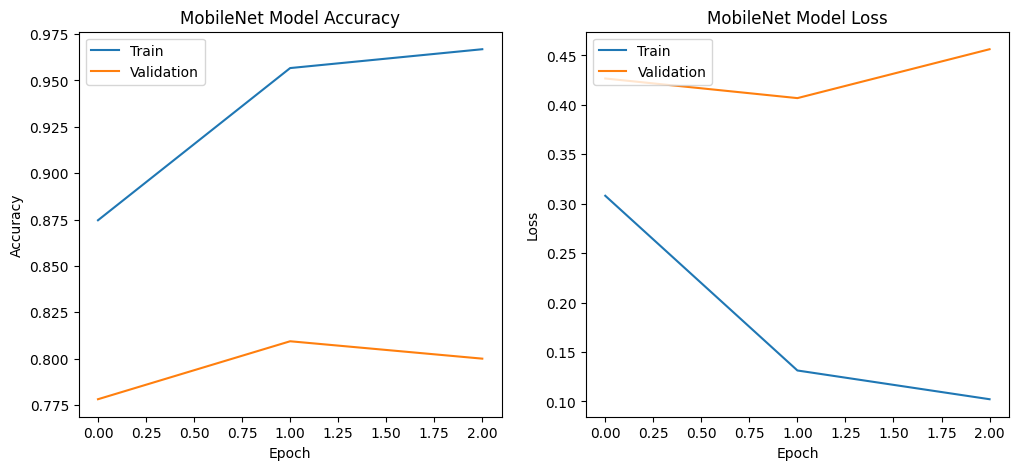

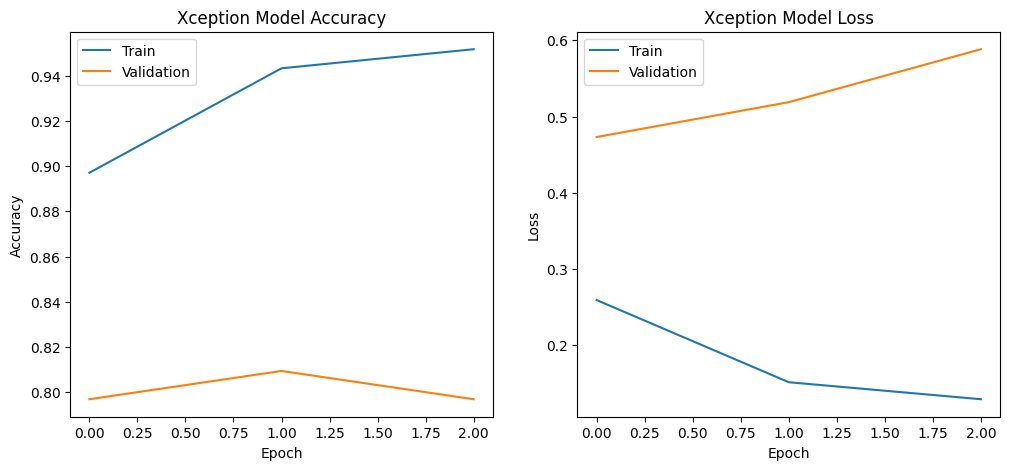

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{model_name} Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{model_name} Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()


plot_history(cnn_history, "CNN")
plot_history(alexnet_history, "AlexNet")
plot_history(vgg16_history, "VGG16")
plot_history(vgg19_history, "VGG19")
plot_history(mobilenet_history, "MobileNet")
plot_history(xception_history, "Xception")